# 03 — Archetype plots

All the standard figures from the saved pipeline outputs: endmember loadings,
abundance distributions, loading heatmap, reconstruction histograms, and the
noise-floor / abundance-weighted-relevance diagnostics.

Run `02_unmixing_pipeline.ipynb` or `python scripts/run_pipeline.py` first.

In [1]:
import sys
sys.path.append('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.config import load_config

sns.set_style('whitegrid')
config = load_config()

In [2]:
from src.data.loading import load_processed

endmembers, abundances_df, meta = load_processed(config)
arch_cols = list(endmembers.columns)
candidate_labels = list(endmembers.index)
M = endmembers.to_numpy()                      # (L candidates, p archetypes)
A = abundances_df[arch_cols].to_numpy().T      # (p archetypes, N precincts)
L, p = M.shape
print(f'{L} candidates, {p} archetypes, {A.shape[1]:,} precincts')

42 candidates, 7 archetypes, 92,486 precincts


## Endmember loadings — top candidates per archetype

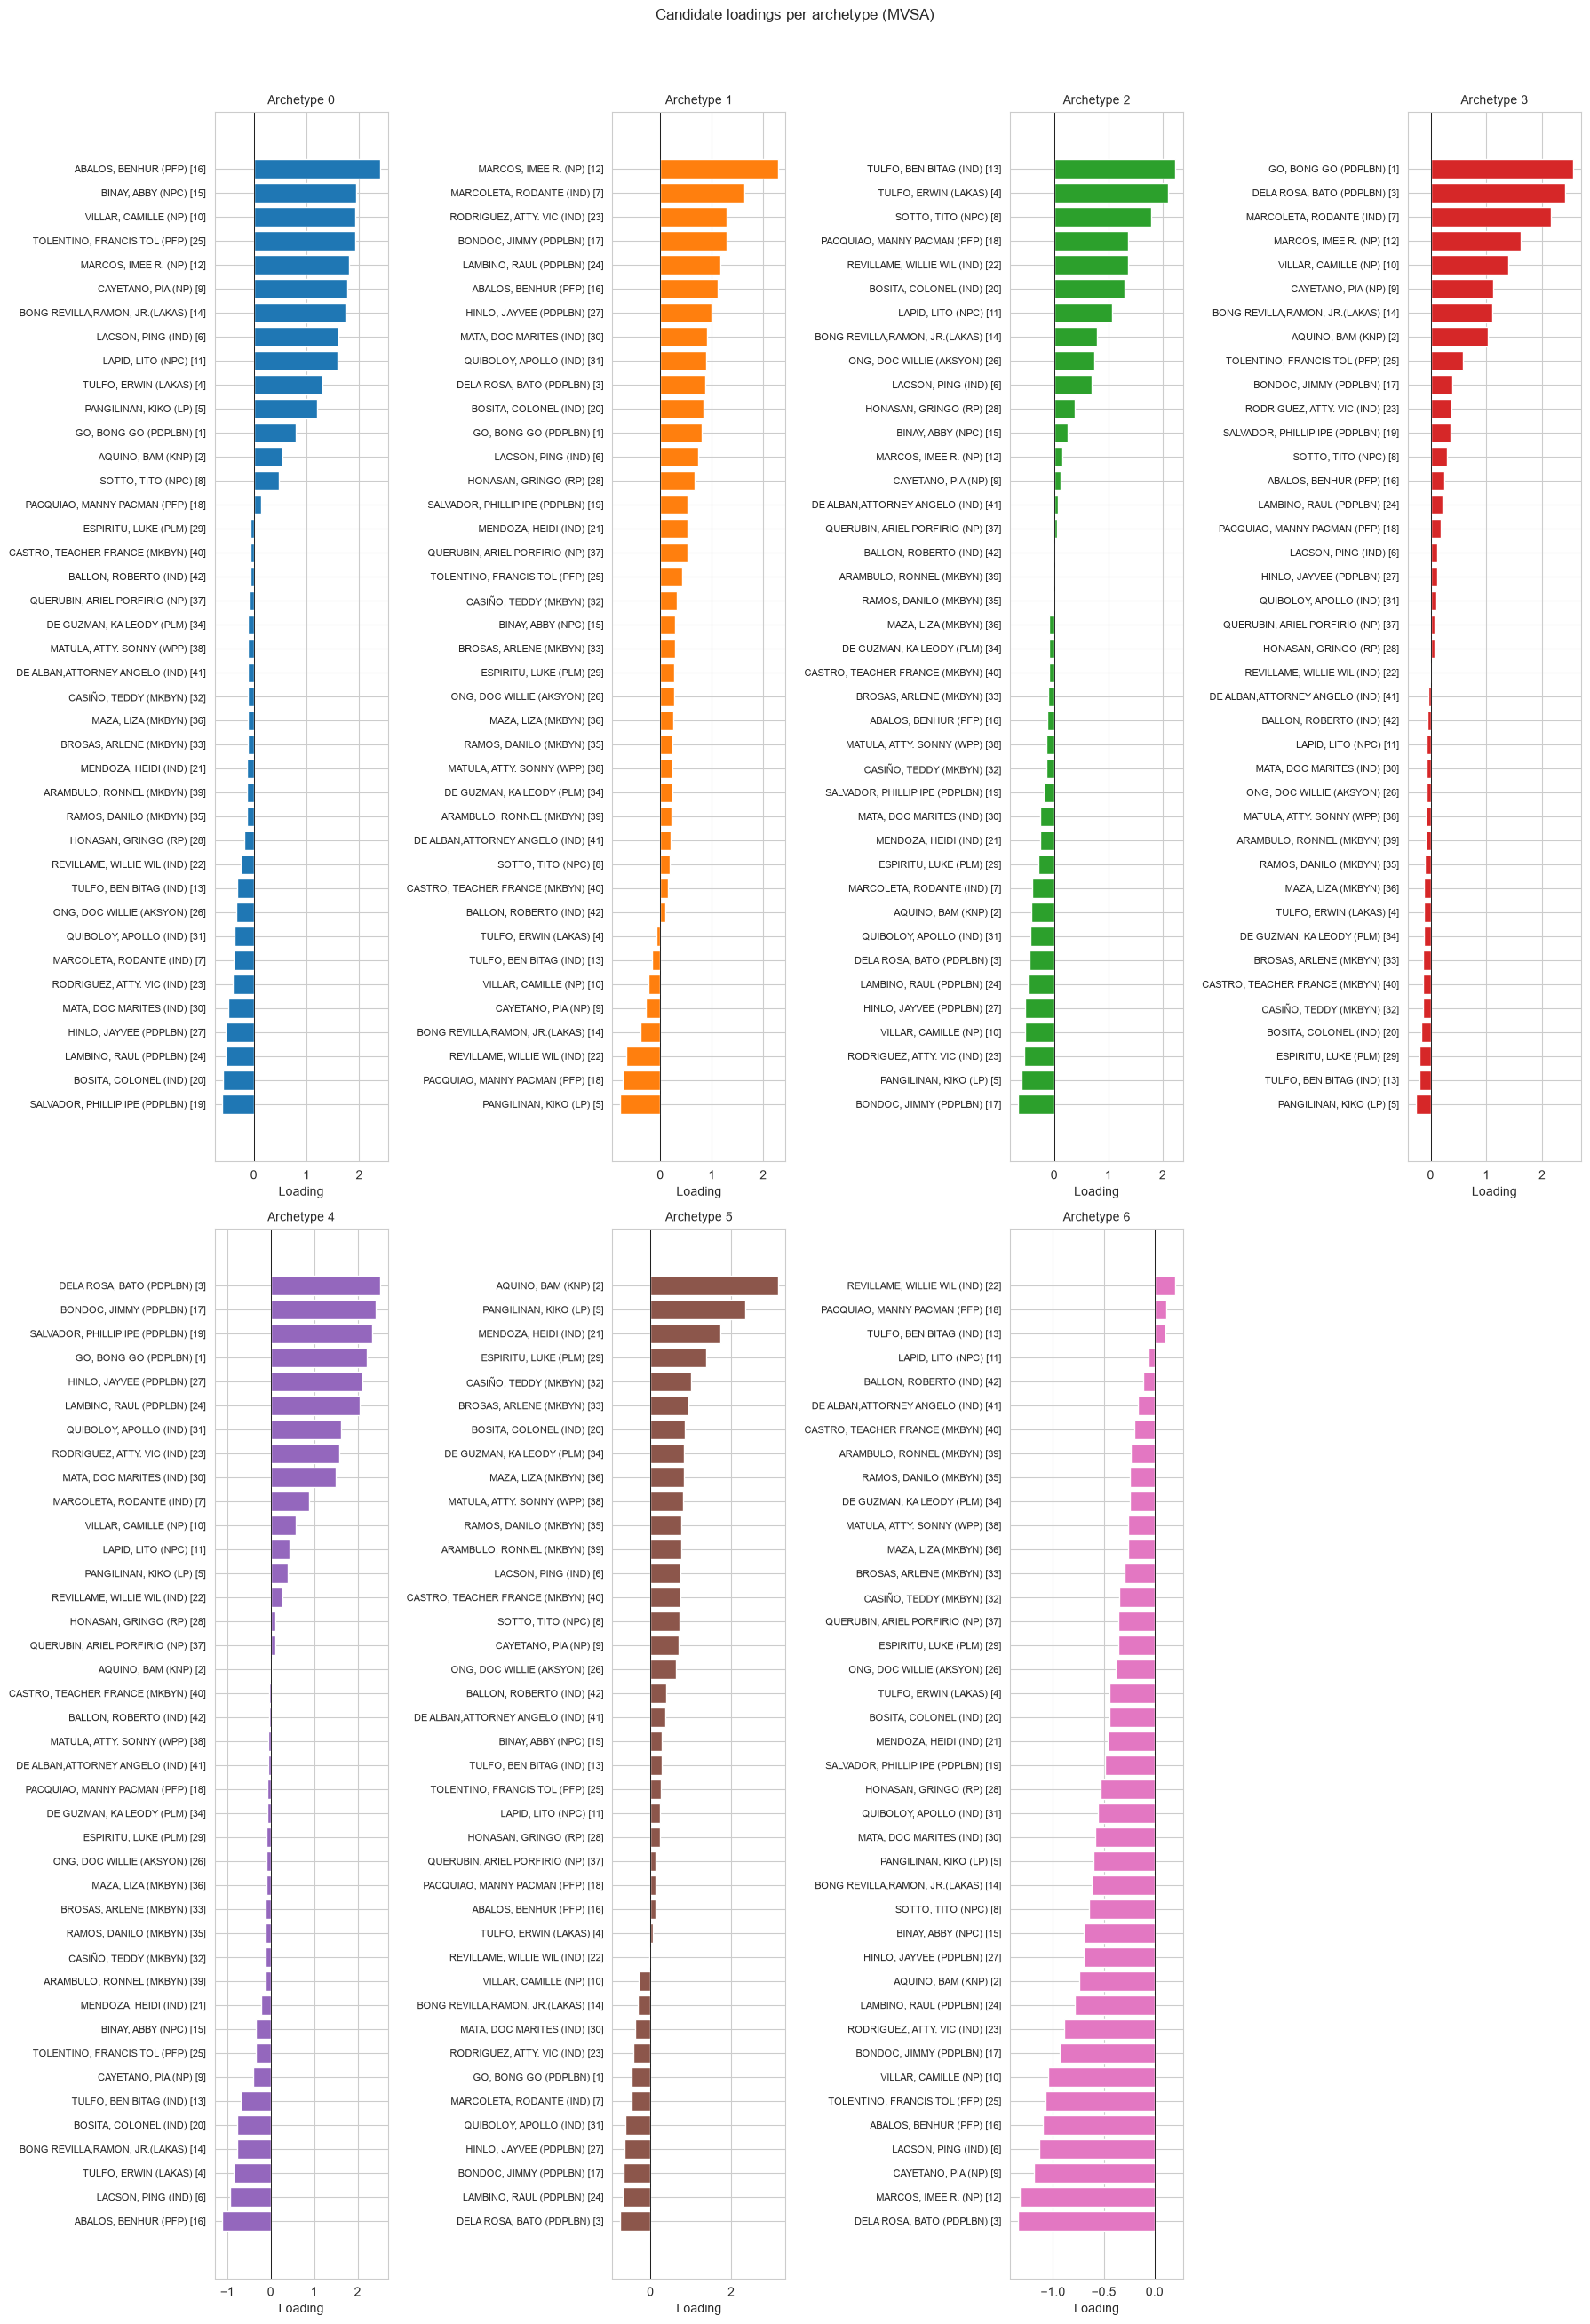

In [3]:
from src.figures import plot_archetypes_loadings_grid

plot_archetypes_loadings_grid(M, candidate_labels, top_n=40,
                              suptitle='Candidate loadings per archetype (MVSA)')

## Loadings vs. candidate rank (archetype spectra)

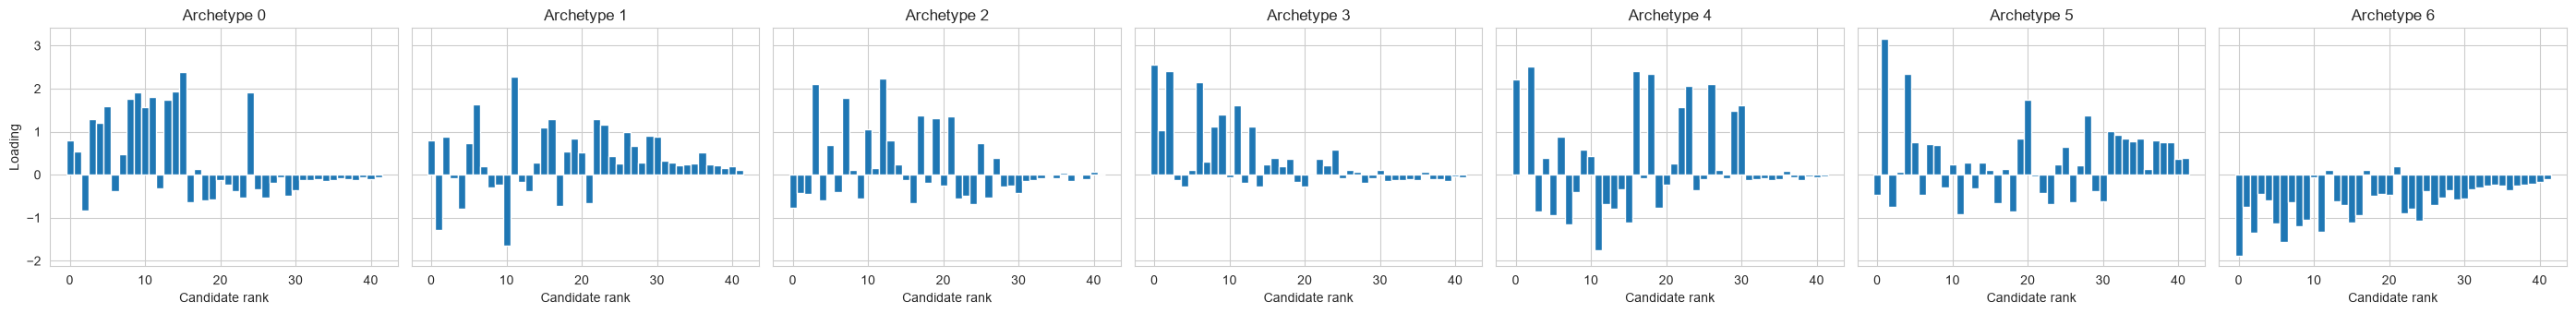

In [4]:
fig, axes = plt.subplots(1, p, figsize=(4 * p, 3.5), sharey=True)
for j, ax in enumerate(np.atleast_1d(axes)):
    ax.bar(range(L), M[:, j], color='C0', width=1.0)
    ax.set_xlabel('Candidate rank')
    ax.set_title(f'Archetype {j}')
np.atleast_1d(axes)[0].set_ylabel('Loading')
fig.tight_layout()

## Loading heatmap (candidates × archetypes)

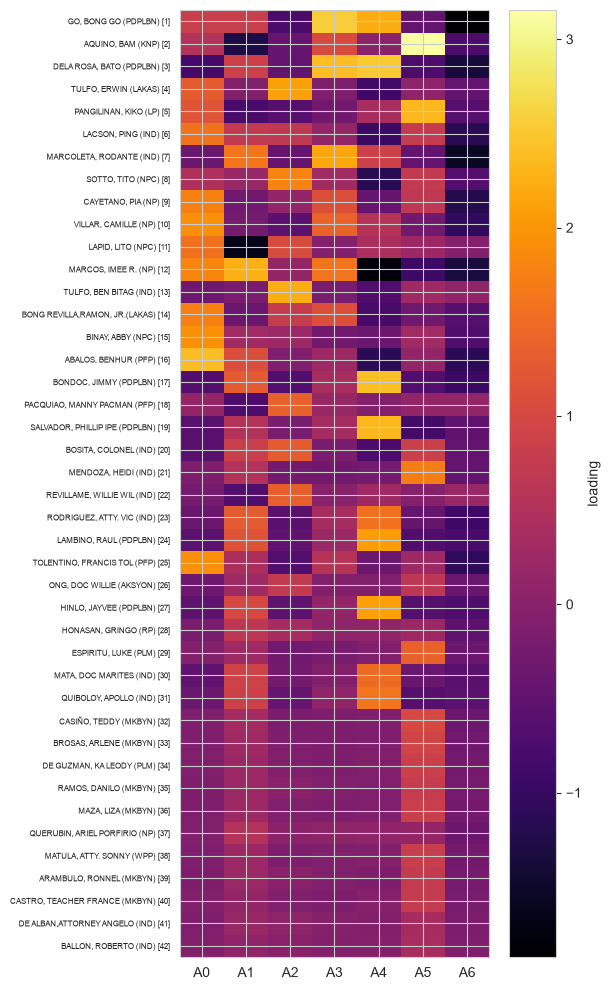

In [5]:
plt.figure(figsize=(6, 10))
plt.imshow(M, cmap='inferno', aspect='auto')
plt.yticks(ticks=np.arange(L), labels=candidate_labels, fontsize=6)
plt.xticks(ticks=np.arange(p), labels=[f'A{j}' for j in range(p)])
plt.colorbar(label='loading')
plt.tight_layout()

## Per-precinct abundance distributions

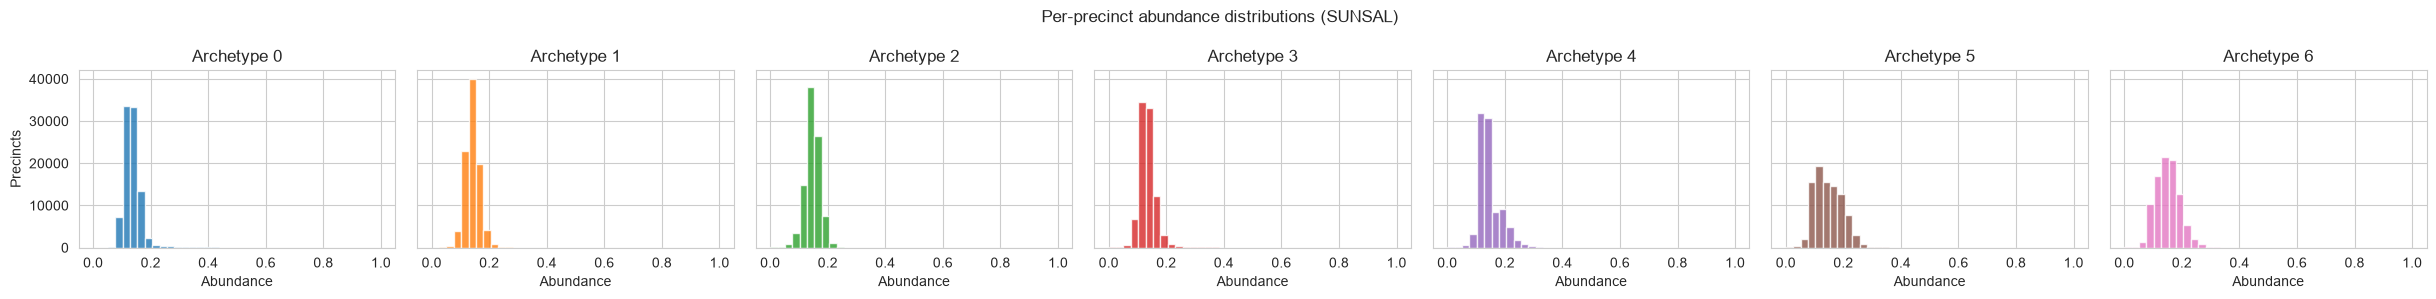

In [6]:
fig, axes = plt.subplots(1, p, figsize=(3.5 * p, 3), sharey=True)
bins = np.linspace(0, 1, 40)
for j, ax in enumerate(np.atleast_1d(axes)):
    ax.hist(A[j, :], bins=bins, color=f'C{j}', edgecolor='white', alpha=0.8)
    ax.set_xlabel('Abundance')
    ax.set_title(f'Archetype {j}')
np.atleast_1d(axes)[0].set_ylabel('Precincts')
fig.suptitle('Per-precinct abundance distributions (SUNSAL)')
fig.tight_layout()

## Reconstruction histograms

Needs the vote matrix — recompute the (fast) preprocessing step.

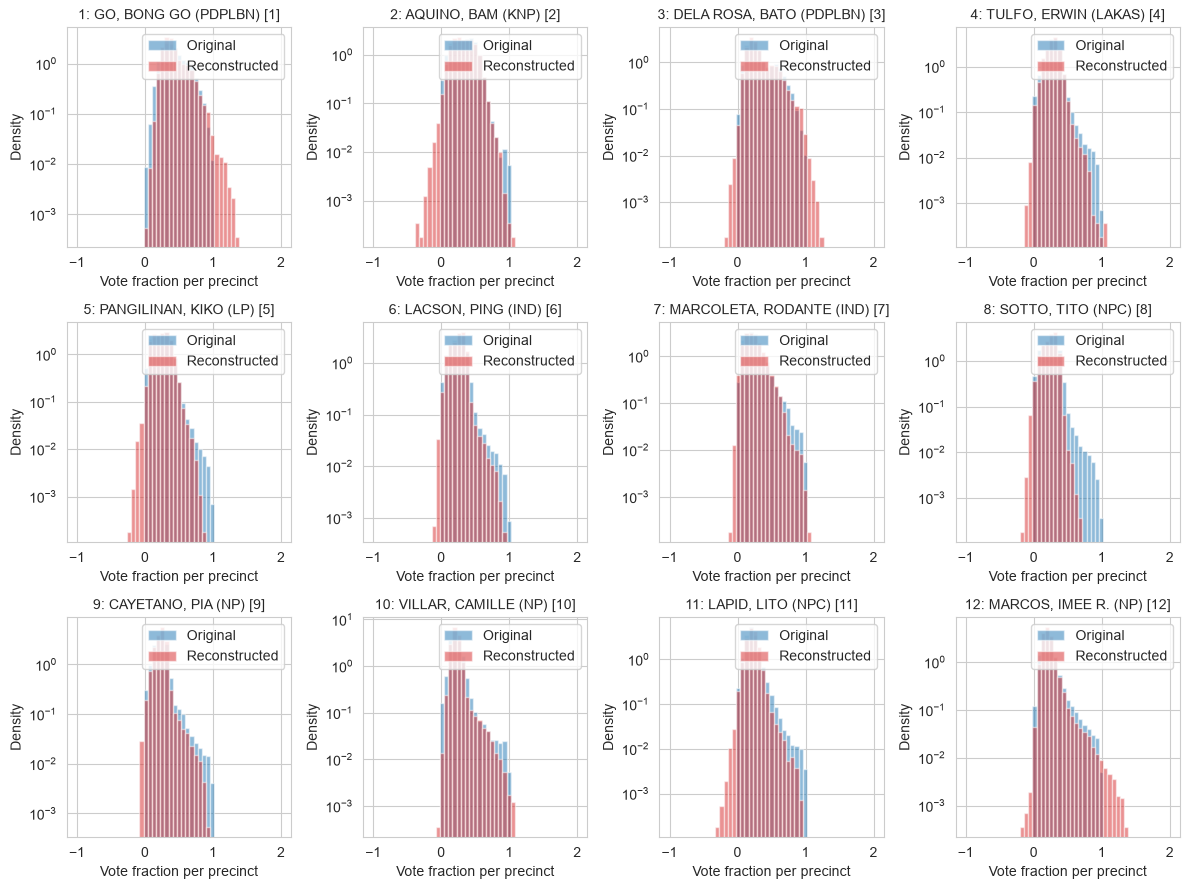

In [7]:
from src.data import load_complete
from src.data.preprocessing import preprocess_from_config
from src.figures import plot_reconstruction_histograms

df = load_complete(config)
pre = preprocess_from_config(df, config, verbose=False)
Y = pre.Y
Y_rec = M @ A

plot_reconstruction_histograms(
    Y, Y_rec,
    top_n_index=list(range(12)),          # rows already rank-ordered
    top_n_names=candidate_labels[:12])

## Noise floor + abundance-weighted candidate relevance

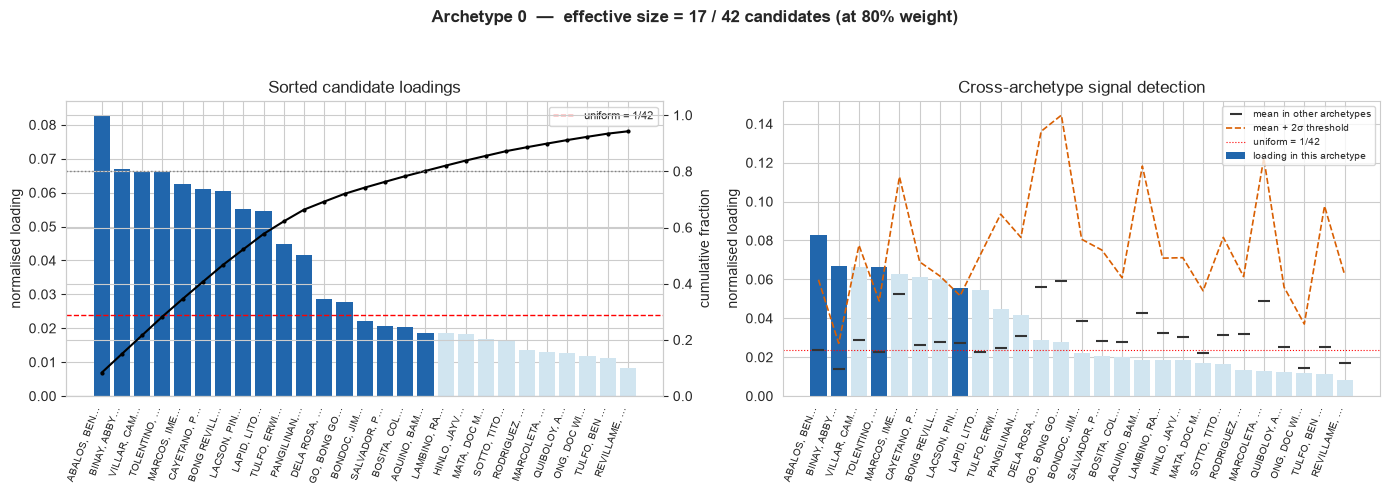

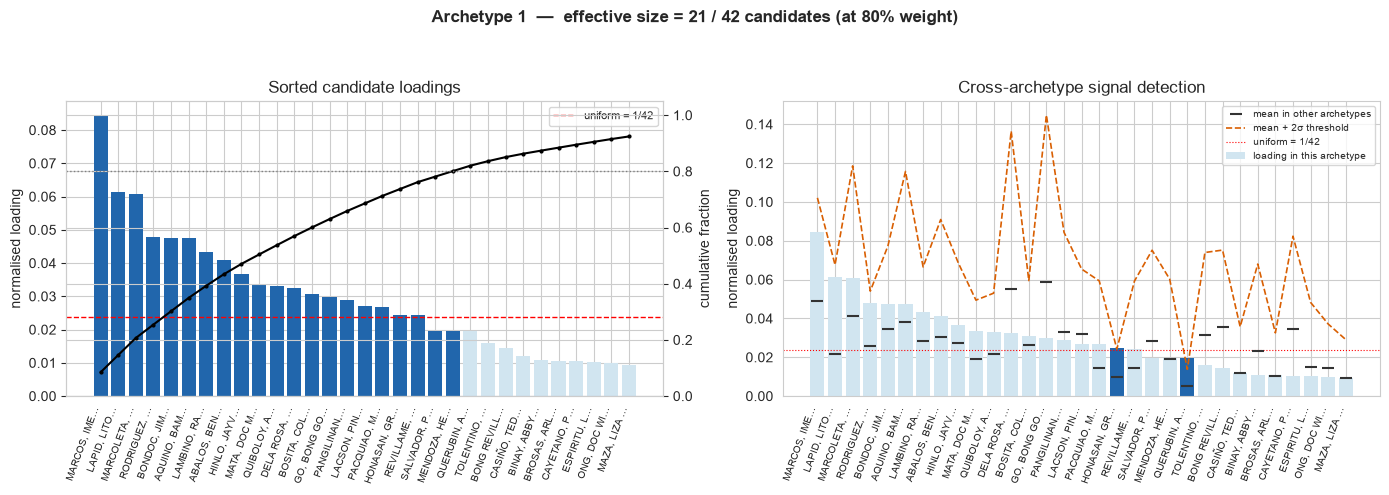

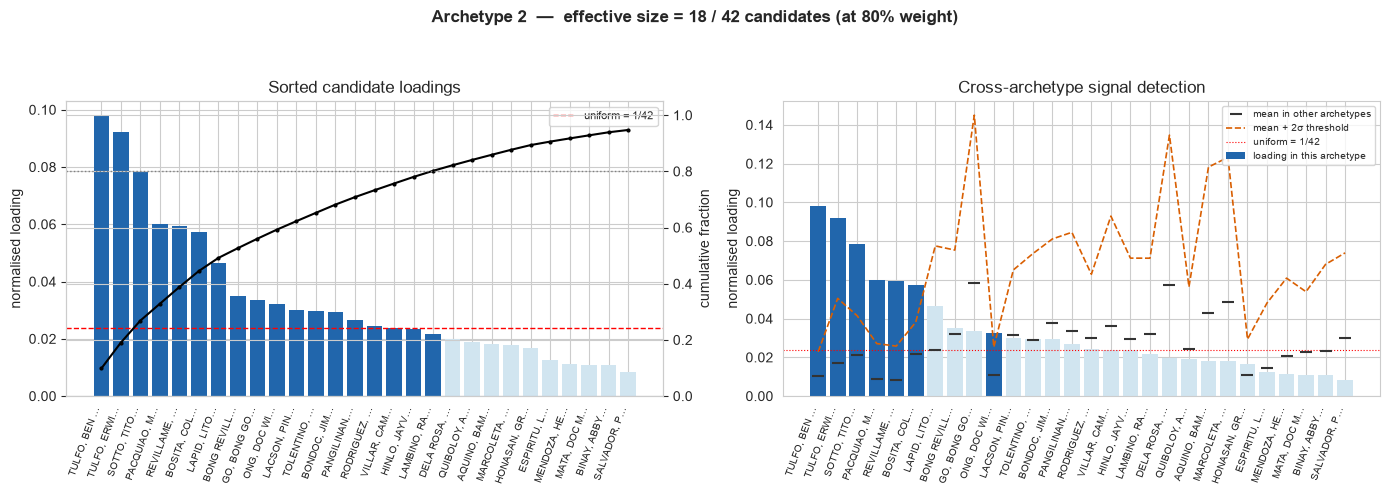

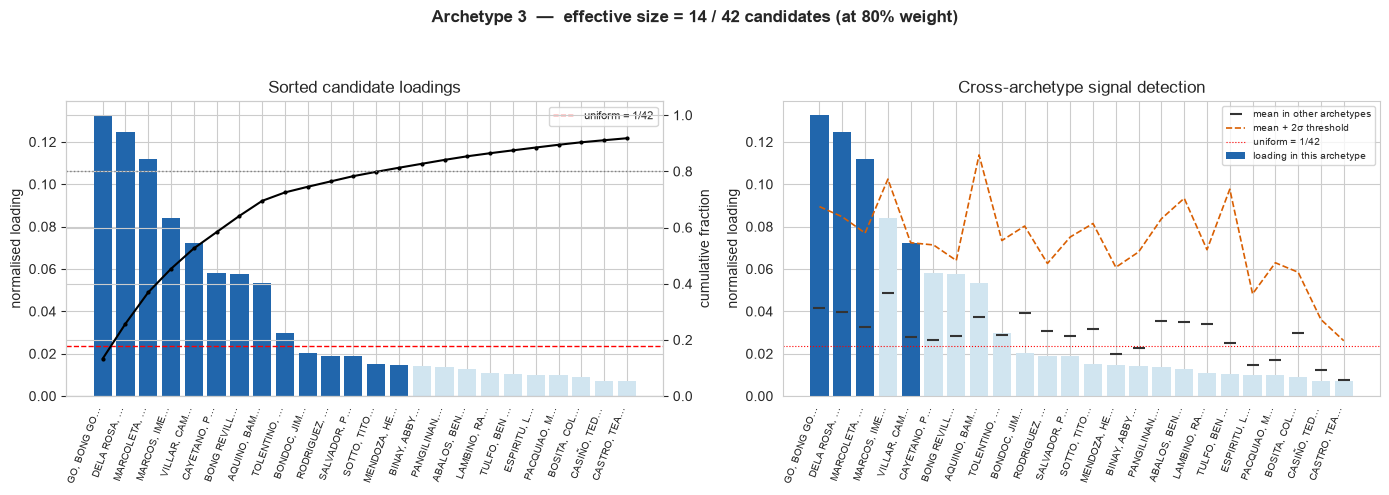

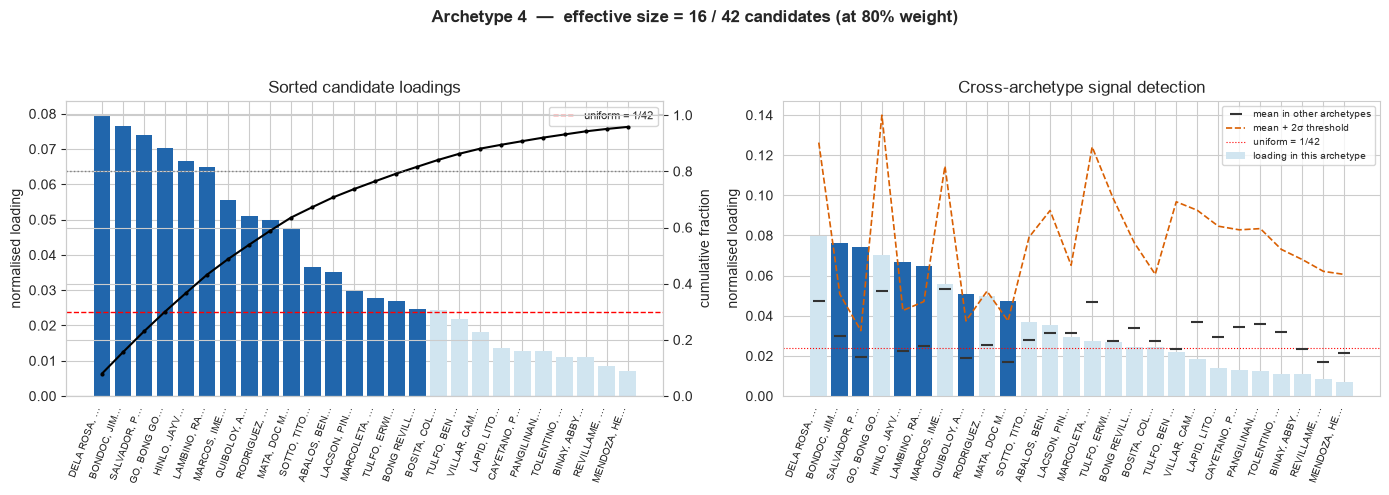

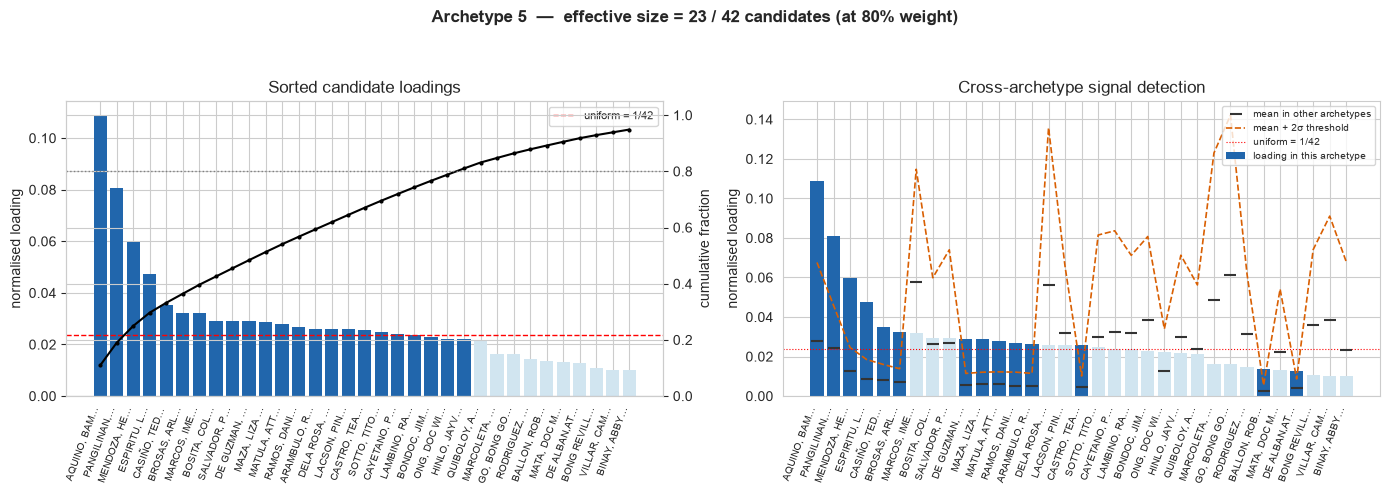

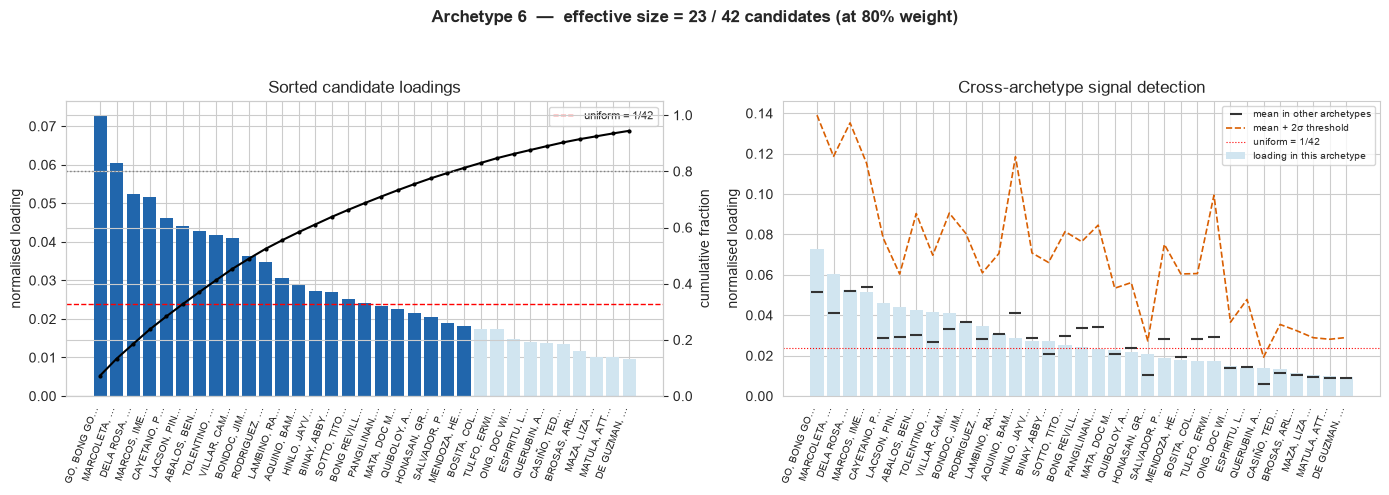

effective archetype sizes: [17 21 18 14 16 23 23]


In [8]:
from src.unmixing import endmember_noise_floor, abundance_weighted_signal

noise_results = endmember_noise_floor(
    M, candidate_labels=candidate_labels,
    cumulative_threshold=0.80, cross_archetype_sigma=2.0, plot=True)
print('effective archetype sizes:', noise_results['summary'])

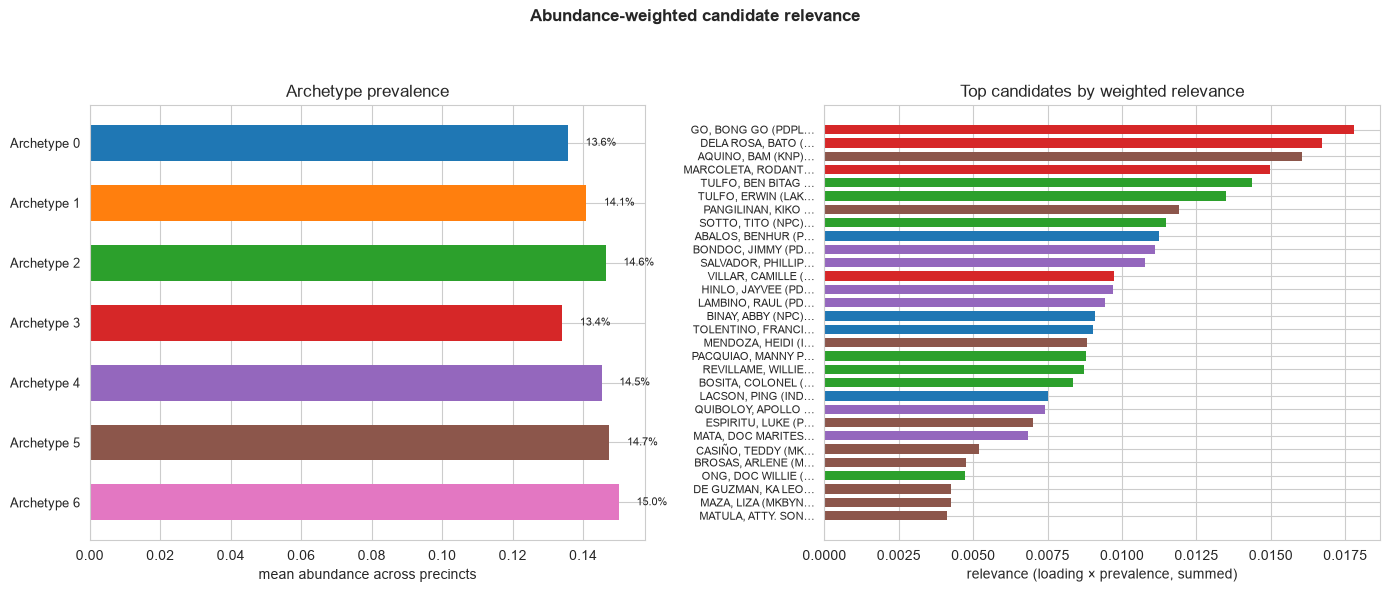

Archetype 0: 13.6%
Archetype 1: 14.1%
Archetype 2: 14.6%
Archetype 3: 13.4%
Archetype 4: 14.5%
Archetype 5: 14.7%
Archetype 6: 15.0%


In [9]:
aw = abundance_weighted_signal(noise_results, A,
                               candidate_labels=candidate_labels, plot=True)
for j, prev in enumerate(aw['archetype_prevalence']):
    print(f'Archetype {j}: {prev:.1%}')